# In this notebook I test whatever question comes up while optimizing the closeness computation.

In [3]:
from datetime import datetime
import rustworkx as rx
import numpy as np

from src.graph_extraction import load_edges

english is my goto test graph

In [6]:
edges = load_edges(lang="en", int_optimize=True)
G = rx.PyGraph(multigraph=False)
G.extend_from_edge_list(edges)

whats actually the speed diff if i do it per node instead of all at the same time?

In [43]:
def mean_harmonic_closeness_per_node(G: rx.PyGraph) -> float:
    N = G.num_nodes()
    total = 0.0
    for u in G.node_indices():
        dists = rx.dijkstra_shortest_path_lengths(G, u, lambda _: 1.0)
        inv_sum = 0.0
        for v, dist in dists.items():
            if v != u and dist > 0:
                inv_sum += 1.0 / dist
        total += inv_sum / (N - 1)
    return total / N

mean_harmonic_closeness_per_node(G)

0.30269292320998487

In [47]:
def mean_harmonic_closeness_all(G: rx.PyGraph) -> float:
    N = G.num_nodes()
    total = 0.0
    dists = rx.all_pairs_dijkstra_path_lengths(G, edge_cost_fn=lambda _: 1.0)
    for u in G.node_indices():
        inv_sum = 0.0
        for v, dist in dists[u].items():
            if v != u and dist > 0:
                inv_sum += 1.0 / dist
        total += inv_sum / (N - 1)
    return total / N


mean_harmonic_closeness_all(G)

0.30269292320998487

In [46]:
def mean_harmonic_closeness_np(G: rx.PyGraph) -> float:
    N = G.num_nodes()
    distances = rx.all_pairs_dijkstra_path_lengths(G, edge_cost_fn=lambda _: 1)
    closeness = np.zeros(N)
    for i, dists in enumerate(distances.values()):
        inv_dists = 1 / np.fromiter(dists.values(), dtype=float)
        closeness[i] = (1 / (N - 1)) * np.sum(inv_dists)

    return closeness.mean()

mean_harmonic_closeness_np(G)

np.float64(0.30269292320998903)

getting #leaves for lkeave parents -> getting distance for the parent with most leave childs yields many closeness results immediately!??

In [48]:
deg = {u: G.degree(u) for u in G.node_indices()}

In [50]:
leaf_count = {u: 0 for u in deg.keys()}
for u, d in deg.items():
    if d == 1:
        v = next(iter(G.neighbors(u)))
        leaf_count[v] += 1

parents = [v for v, count in leaf_count.items() if count > 0]
parents.sort(key=lambda v: (-(1 + leaf_count[v]), deg[v]))

deg 0 impossible since nodes come from edges and self loops are excluded by design, however sanity check

In [51]:
len([u for u, d in deg.items() if d == 0])

0

In [52]:
len(G.node_indices())

4653

In [53]:
len([d for d in deg.values() if d == 1])

1060

In [54]:
max(leaf_count.values())

11

well I guess I was a bit optimistic here :D "many"

In [18]:
len(parents)

782

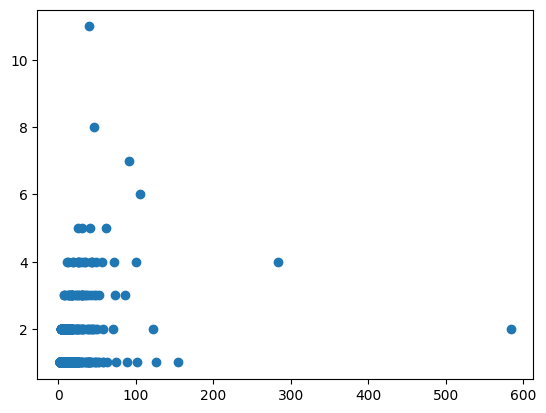

In [ ]:
from matplotlib import pyplot as plt

pairs = [(deg[u], leaf_count[u]) for u in parents]
x, y = map(np.array, zip(*pairs))

plt.plot(x, y, "o", linestyle="None")

We might be able to have a tighter bound if the graph is fragmented?

In [ ]:
from src.utils import LANG_DICT

num_components = {}
for lang in LANG_DICT.keys():
    edges = load_edges(lang=lang, int_optimize=True)
    G = rx.PyGraph(multigraph=False)
    G.extend_from_edge_list(edges)
    num_components[lang] = len(rx.connected_components(G))
    if num_components[lang] > 1:
        print(f"{lang}: {num_components[lang]} components")
        print([len(c) for c in rx.connected_components(G)])

cs: 2 components
[5300, 2]
pl: 2 components
[5017, 2]
zh: 3 components
[5414, 4, 2]


: 